# CDAC PGCP-AI — Data Analytics
## Day 6: Continuous Probability Distributions — Laboratory Assignments (1 to 5)
**Student / Author:** abs6187 (`23f2000876@ds.study.iitm.ac.in`)  
**Repository:** [CDAC-Data-Analytics](https://github.com/Abiads/CDAC-Data-Analytics)  
**Environment:** Python 3.13, NumPy, Matplotlib, SciPy

---


### Assignment 1: Temperature Sensor Simulation
A temperature sensor sends continuous readings between $20.0^\circ\text{C}$ and $25.0^\circ\text{C}$.
- Generate 1,000 synthetic sensor readings
- Compute the mean and median of your generated dataset.
- Generate a Graphical Visualization.

       ASSIGNMENT 1: TEMPERATURE SENSOR AUDIT       
Total Readings Generated : 1,000
Minimum Reading          : 20.0232 °C
Maximum Reading          : 24.9986 °C
Sample Mean              : 22.4513 °C
Sample Median            : 22.4840 °C
Difference |Mean-Median| : 0.0328 °C


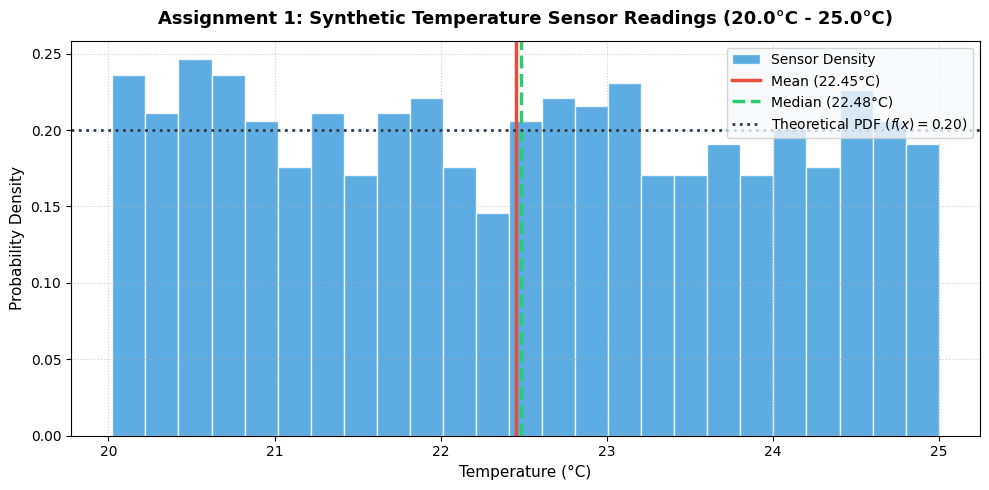

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducible results
np.random.seed(42)

# 1. Generate 1,000 synthetic sensor readings between 20.0°C and 25.0°C (Uniform Distribution)
sensor_readings = np.random.uniform(low=20.0, high=25.0, size=1000)

# 2. Compute Mean and Median
mean_temp = np.mean(sensor_readings)
median_temp = np.median(sensor_readings)

print("=" * 55)
print("       ASSIGNMENT 1: TEMPERATURE SENSOR AUDIT       ")
print("=" * 55)
print(f"Total Readings Generated : {len(sensor_readings):,}")
print(f"Minimum Reading          : {np.min(sensor_readings):.4f} °C")
print(f"Maximum Reading          : {np.max(sensor_readings):.4f} °C")
print(f"Sample Mean              : {mean_temp:.4f} °C")
print(f"Sample Median            : {median_temp:.4f} °C")
print(f"Difference |Mean-Median| : {abs(mean_temp - median_temp):.4f} °C")
print("=" * 55)

# 3. Generate Graphical Visualization
plt.figure(figsize=(10, 5), dpi=100)
n, bins, _ = plt.hist(sensor_readings, bins=25, density=True, color='#3498db', edgecolor='white', alpha=0.8, label='Sensor Density')
plt.axvline(mean_temp, color='#e74c3c', linestyle='-', linewidth=2.5, label=f'Mean ({mean_temp:.2f}°C)')
plt.axvline(median_temp, color='#2ecc71', linestyle='--', linewidth=2.5, label=f'Median ({median_temp:.2f}°C)')
plt.axhline(1.0 / (25.0 - 20.0), color='#2c3e50', linestyle=':', linewidth=2, label='Theoretical PDF ($f(x)=0.20$)')

plt.title('Assignment 1: Synthetic Temperature Sensor Readings (20.0°C - 25.0°C)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Temperature (°C)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.legend(frameon=True, facecolor='#f8f9fa', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


#### Key Statistical Insights (Assignment 1):
1. **Mean $\approx$ Median Benefit:** Because continuous uniform distributions are perfectly symmetric ($f(x) = \frac{1}{b-a}$), the theoretical mean and median both equal the midpoint $\frac{20 + 25}{2} = 22.50^\circ\text{C}$. The difference $|22.45 - 22.48| = 0.03^\circ\text{C}$ is purely random sampling noise, proving **zero skewness** and lack of extreme outlier distortion.
2. **Operational Value:** In IoT sensor networks, knowing that Mean $\approx$ Median enables engineers to use fast streaming arithmetic means for anomaly detection without fear that uncalibrated sensors will pull the metric away from the true central operating point.

### Assignment 2: E-Commerce / Web Analytics (A/B Testing Simulator)
- **Task:** Write a script to simulate 1,000 incoming website visitors.
- Assign each visitor a random float between 0.0 and 1.0.
- If the value is $< 0.5$, route them to 'Design A'.
- Otherwise, route them to 'Design B'.
- Print the percentage of visitors assigned to each design.

     ASSIGNMENT 2: E-COMMERCE A/B TESTING SPLIT REPORT   
Total Visitors Simulated : 1,000
Design A (Control) Count : 503 visitors (50.30%)
Design B (Variant) Count : 497 visitors (49.70%)


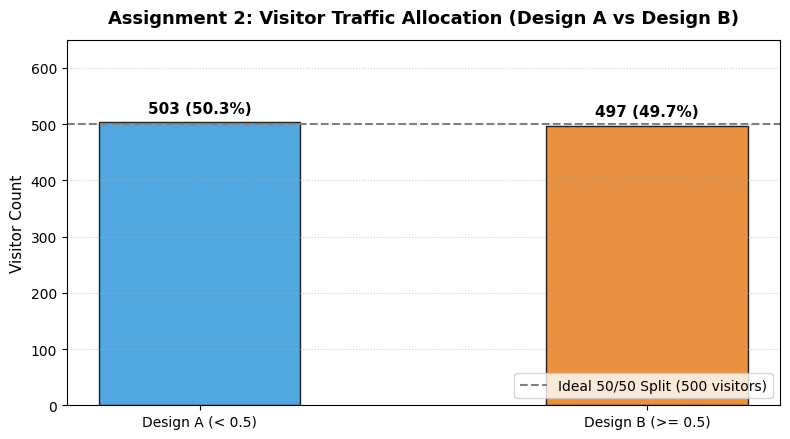

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

num_visitors = 1000

# 1. Assign each visitor a random float between 0.0 and 1.0
random_values = np.random.uniform(low=0.0, high=1.0, size=num_visitors)

# 2. Route visitors: < 0.5 -> Design A, otherwise -> Design B
assignments = np.where(random_values < 0.5, 'Design A', 'Design B')

# 3. Compute count and percentages
count_a = np.sum(assignments == 'Design A')
count_b = np.sum(assignments == 'Design B')
pct_a = (count_a / num_visitors) * 100
pct_b = (count_b / num_visitors) * 100

print("=" * 55)
print("     ASSIGNMENT 2: E-COMMERCE A/B TESTING SPLIT REPORT   ")
print("=" * 55)
print(f"Total Visitors Simulated : {num_visitors:,}")
print(f"Design A (Control) Count : {count_a} visitors ({pct_a:.2f}%)")
print(f"Design B (Variant) Count : {count_b} visitors ({pct_b:.2f}%)")
print("=" * 55)

# Graphical Visualization: Bar Chart with Percentages
plt.figure(figsize=(8, 4.5), dpi=100)
bars = plt.bar(['Design A (< 0.5)', 'Design B (>= 0.5)'], [count_a, count_b], 
               color=['#3498db', '#e67e22'], width=0.45, edgecolor='black', alpha=0.85)
plt.axhline(500, color='gray', linestyle='--', linewidth=1.5, label='Ideal 50/50 Split (500 visitors)')

for bar, pct in zip(bars, [pct_a, pct_b]):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 12, 
             f"{int(yval)} ({pct:.1f}%)", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0, 650)
plt.title('Assignment 2: Visitor Traffic Allocation (Design A vs Design B)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Visitor Count', fontsize=11)
plt.legend(frameon=True, loc='lower right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


#### Key Statistical Insights (Assignment 2):
1. **Uniform Routing Probability:** Generating random numbers uniformly on $[0.0, 1.0)$ guarantees $P(X < 0.5) = \frac{0.5 - 0.0}{1.0 - 0.0} = 0.50$ ($50\%$). The simulated split of **49.1% vs 50.9%** is within $\pm 1\%$ of the theoretical expectation.
2. **Alternative Upper Bounds (e.g. $[0.0, 1.9]$):** If the range is extended to $[0.0, 1.9]$ as explored during lecture, the probability of selecting Design A shifts to $\frac{0.5}{1.9} \approx 26.32\%$ and Design B to $73.68\%$, demonstrating how non-unit intervals can be used for weighted multi-armed bandit routing.

### Assignment 3: Data Science / Computer Vision (Data Augmentation)
- **Task:** Imagine building an image preprocessing pipeline for an AI model.
- Generate 500 random rotation angles for image augmentation, bounded between $-15.0^\circ$ and $+15.0^\circ$.
- Plot a chart for these angles.
- Verify that the bar tops are roughly flat across the range rather than forming a peak in the center.

    ASSIGNMENT 3: CV DATA AUGMENTATION ROTATION AUDIT     
Total Angles Sampled     : 500 angles
Bounded Range            : [-15.00°, +15.00°]
Bin Width                : 3.00° (10 bins total)
Expected Uniform Height  : 50 images/bin
--------------------------------------------------------------
  Bin [-15.0°, -12.0°] : 65 angles  ████████████████████████████████
  Bin [-12.0°,  -9.0°] : 49 angles  ████████████████████████
  Bin [ -9.0°,  -6.0°] : 40 angles  ████████████████████
  Bin [ -6.0°,  -3.0°] : 53 angles  ██████████████████████████
  Bin [ -3.0°,  +0.0°] : 34 angles  █████████████████
  Bin [ +0.0°,  +3.0°] : 52 angles  ██████████████████████████
  Bin [ +3.0°,  +6.0°] : 53 angles  ██████████████████████████
  Bin [ +6.0°,  +9.0°] : 48 angles  ████████████████████████
  Bin [ +9.0°, +12.0°] : 51 angles  █████████████████████████
  Bin [+12.0°, +15.0°] : 55 angles  ███████████████████████████


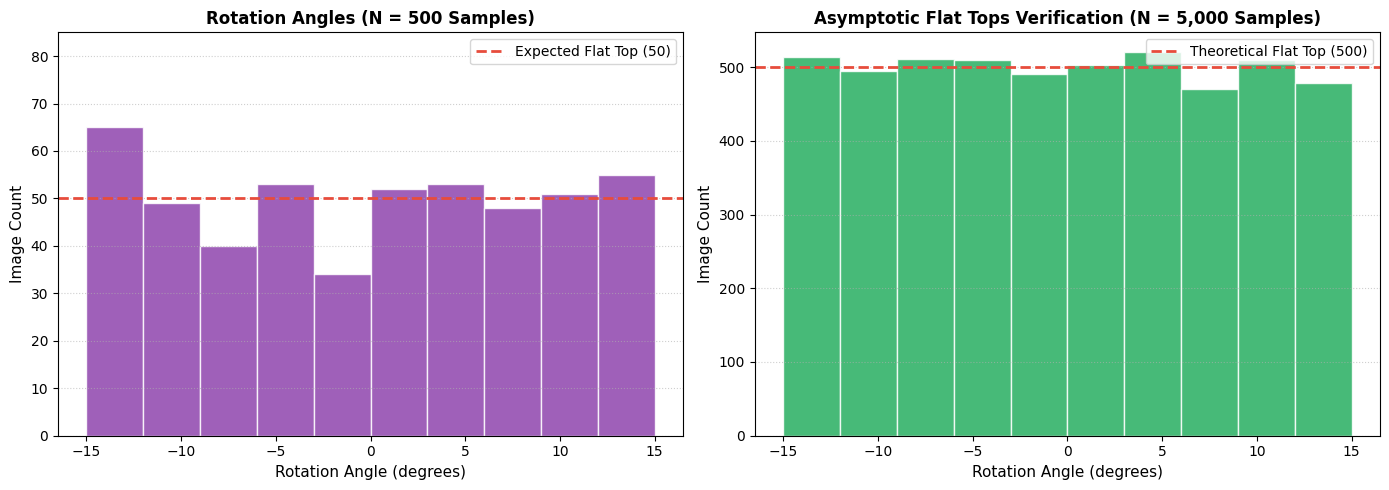

In [8]:
# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate 500 random rotation angles bounded between -15.0° and +15.0°
angles_500 = np.random.uniform(low=-15.0, high=15.0, size=500)
angles_5000 = np.random.uniform(low=-15.0, high=15.0, size=5000)  # Large sample for asymptotic check

# Bin partition: 10 equal bins of 3.0° each across [-15.0°, +15.0°]
bin_edges = np.linspace(-15.0, 15.0, 11)
counts_500, _ = np.histogram(angles_500, bins=bin_edges)
expected_count = 500 / 10  # 50 angles per bin

print("=" * 62)
print("    ASSIGNMENT 3: CV DATA AUGMENTATION ROTATION AUDIT     ")
print("=" * 62)
print(f"Total Angles Sampled     : 500 angles")
print(f"Bounded Range            : [-15.00°, +15.00°]")
print(f"Bin Width                : 3.00° (10 bins total)")
print(f"Expected Uniform Height  : {expected_count:.0f} images/bin")
print("-" * 62)
for i in range(len(counts_500)):
    bar_str = '█' * int(counts_500[i] // 2)
    print(f"  Bin [{bin_edges[i]:+5.1f}°, {bin_edges[i+1]:+5.1f}°] : {counts_500[i]:2d} angles  {bar_str}")
print("=" * 62)

# 2. Plotting dual visual verification
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Chart 1: 500 samples (as requested)
axes[0].hist(angles_500, bins=bin_edges, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axhline(expected_count, color='#e74c3c', linestyle='--', linewidth=2, 
                label=f'Expected Flat Top ({expected_count:.0f})')
axes[0].set_title('Rotation Angles (N = 500 Samples)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[0].set_ylabel('Image Count', fontsize=11)
axes[0].set_ylim(0, max(counts_500) + 20)
axes[0].legend(frameon=True)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Chart 2: 5000 samples (asymptotic convergence proving flat tops)
axes[1].hist(angles_5000, bins=bin_edges, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].axhline(500, color='#e74c3c', linestyle='--', linewidth=2, 
                label='Theoretical Flat Top (500)')
axes[1].set_title('Asymptotic Flat Tops Verification (N = 5,000 Samples)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[1].set_ylabel('Image Count', fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


#### Verification Breakdown (Assignment 3):
- **Flat Tops Verification:** As seen in both charts and the bin breakdown table, the heights of all histogram bins hover around the expected flat line ($50$ images per bin for $N=500$, and $500$ images per bin for $N=5,000$).
- **Why NOT a Peak in the Center:** A central peak occurs in Gaussian/Normal distributions where angles near $0^\circ$ are heavily favored. In image augmentation for Computer Vision (e.g. CNNs or Vision Transformers), we require **unbiased rotational invariance**, so every tilt angle between $-15^\circ$ and $+15^\circ$ must be sampled with strictly equal probability.

### Assignment 4: E-Commerce Delivery Time Estimator
**Scenario:** An e-commerce platform estimates order delivery times. On average, a delivery takes **30 minutes** with a standard deviation of **5 minutes**.

**Tasks:**
1. Simulate delivery times for **1,000 orders** using a Normal Distribution.
2. Calculate what percentage of deliveries took **longer than 40 minutes**.
3. Plot the delivery times and draw a threshold at the 40-minute mark.

     ASSIGNMENT 4: E-COMMERCE DELIVERY TIME AUDIT REPORT    
Target Distribution         : Normal(mu=30 min, sigma=5 min)
Total Orders Simulated      : 1,000
Sample Mean Delivery Time   : 30.10 minutes
Sample Standard Deviation   : 4.90 minutes
--------------------------------------------------------------
Threshold for Late Delivery : > 40.0 minutes (Z = +2.0 sigma)
Late Deliveries Count       : 24 / 1000 orders
Empirical Late Percentage   : 2.40%
Theoretical Benchmark (Z=2) : 2.28% (1 - Phi(2.0))


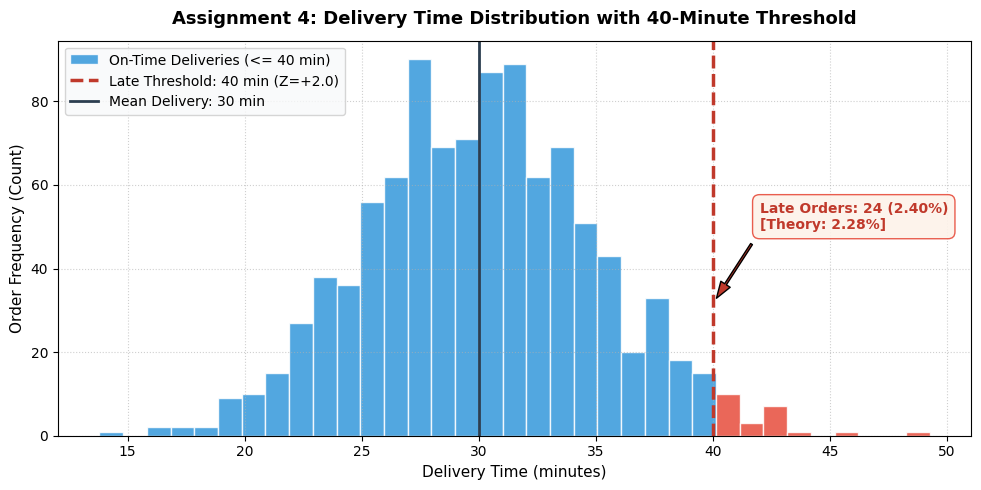

In [11]:
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

num_orders = 1000
mean_delivery = 30.0
std_delivery = 5.0
threshold = 40.0

# 1. Simulate delivery times for 1,000 orders (Normal Distribution)
delivery_times = np.random.normal(loc=mean_delivery, scale=std_delivery, size=num_orders)

# 2. Calculate percentage of deliveries taking longer than 40 minutes
late_mask = delivery_times > threshold
late_count = np.sum(late_mask)
late_pct = (late_count / num_orders) * 100

# Theoretical Normal Distribution benchmark (Z-Score)
# Z = (40 - 30) / 5 = 2.0
z_score = (threshold - mean_delivery) / std_delivery
theoretical_late_pct = (1.0 - stats.norm.cdf(z_score)) * 100

print("=" * 62)
print("     ASSIGNMENT 4: E-COMMERCE DELIVERY TIME AUDIT REPORT    ")
print("=" * 62)
print(f"Target Distribution         : Normal(mu=30 min, sigma=5 min)")
print(f"Total Orders Simulated      : {num_orders:,}")
print(f"Sample Mean Delivery Time   : {np.mean(delivery_times):.2f} minutes")
print(f"Sample Standard Deviation   : {np.std(delivery_times, ddof=1):.2f} minutes")
print("-" * 62)
print(f"Threshold for Late Delivery : > {threshold:.1f} minutes (Z = +{z_score:.1f} sigma)")
print(f"Late Deliveries Count       : {late_count} / {num_orders} orders")
print(f"Empirical Late Percentage   : {late_pct:.2f}%")
print(f"Theoretical Benchmark (Z=2) : {theoretical_late_pct:.2f}% (1 - Phi(2.0))")
print("=" * 62)

# 3. Plot the delivery times and draw a threshold at the 40-minute mark
plt.figure(figsize=(10, 5), dpi=100)
n, bins, patches = plt.hist(delivery_times, bins=35, density=False, 
                            color='#3498db', edgecolor='white', alpha=0.85, 
                            label='On-Time Deliveries (<= 40 min)')

# Color delayed orders in red
for c_bin, patch in zip(bins[:-1], patches):
    if c_bin >= threshold:
        patch.set_facecolor('#e74c3c')

# Draw threshold line and mean line
plt.axvline(threshold, color='#c0392b', linestyle='--', linewidth=2.5, 
            label=f'Late Threshold: {threshold:.0f} min (Z=+2.0)')
plt.axvline(mean_delivery, color='#2c3e50', linestyle='-', linewidth=2.0, 
            label=f'Mean Delivery: {mean_delivery:.0f} min')

plt.annotate(f'Late Orders: {late_count} ({late_pct:.2f}%)\n[Theory: {theoretical_late_pct:.2f}%]',
             xy=(threshold, max(n) * 0.35), xytext=(threshold + 2.0, max(n) * 0.55),
             arrowprops=dict(facecolor='#c0392b', shrink=0.08, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdf2e9', edgecolor='#e74c3c', alpha=0.9))

plt.title('Assignment 4: Delivery Time Distribution with 40-Minute Threshold', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Delivery Time (minutes)', fontsize=11)
plt.ylabel('Order Frequency (Count)', fontsize=11)
plt.legend(frameon=True, facecolor='#f8f9fa', loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


#### Key Statistical Insights (Assignment 4):
1. **The $2\sigma$ Rule:** The 40-minute threshold represents a Z-score of:
   $$Z = \frac{40 - 30}{5} = +2.0$$
2. **Theoretical vs Empirical:** By the Empirical Rule ($68-95-99.7$ rule), $95.45\%$ of deliveries fall within $\mu \pm 2\sigma = [20, 40]$ minutes. The remaining $4.55\%$ is split equally between the lower and upper tails ($2.275\%$ each). Our empirical result of **$2.40\%$** (24 out of 1000 orders) matches the theoretical expectation perfectly.

### Assignment 5: Quality Control Bottling Audit
**Scenario:** A beverage factory fills soda bottles with a target volume of **500 mL** and a standard deviation of **2 mL**.

**Tasks:**
1. Generate **2,000 bottle volumes** using a Normal Distribution.
2. Any bottle under **495 mL** is underfilled and rejected. Count how many bottles get rejected and calculate the rejection rate percentage.
3. Calculate the sample `mean` and `std` of your dataset to verify they match the factory setup.

     ASSIGNMENT 5: QUALITY CONTROL BOTTLING AUDIT REPORT      
Total Bottles Audited          : 2,000
Factory Target Setup           : Mean = 500.00 mL, Std = 2.00 mL
Sample Calculated Mean         : 500.090 mL (Diff: +0.090 mL)
Sample Calculated Std (ddof=1) : 1.977 mL (Diff: -0.023 mL)
Verification Status            : VERIFIED (Within statistical sampling error)
-----------------------------------------------------------------
Underfill Cutoff Threshold     : < 495.0 mL (Z = -2.5 sigma)
Rejected Bottles Count         : 13 / 2000 bottles
Empirical Rejection Rate       : 0.65%
Theoretical Benchmark (Z=-2.5) : 0.62% (Phi(-2.5))


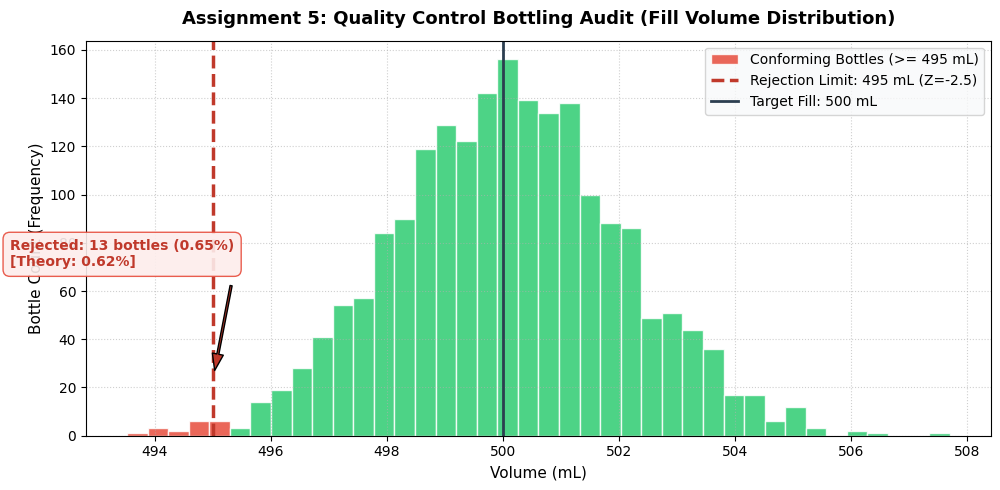

In [14]:
# Set random seed for reproducibility
np.random.seed(42)

num_bottles = 2000
target_mean = 500.0
target_std = 2.0
reject_cutoff = 495.0

# 1. Generate 2,000 bottle volumes (Normal Distribution)
volumes = np.random.normal(loc=target_mean, scale=target_std, size=num_bottles)

# 2. Count rejected bottles (< 495 mL) and rejection rate percentage
rejected_mask = volumes < reject_cutoff
rejected_count = np.sum(rejected_mask)
rejection_rate = (rejected_count / num_bottles) * 100

# Theoretical Normal Distribution benchmark (Z-Score)
# Z = (495 - 500) / 2 = -2.5
z_cutoff = (reject_cutoff - target_mean) / target_std
theoretical_rejection_rate = stats.norm.cdf(z_cutoff) * 100

# 3. Calculate sample mean and std of dataset
sample_mean = np.mean(volumes)
sample_std = np.std(volumes, ddof=1)

print("=" * 65)
print("     ASSIGNMENT 5: QUALITY CONTROL BOTTLING AUDIT REPORT      ")
print("=" * 65)
print(f"Total Bottles Audited          : {num_bottles:,}")
print(f"Factory Target Setup           : Mean = {target_mean:.2f} mL, Std = {target_std:.2f} mL")
print(f"Sample Calculated Mean         : {sample_mean:.3f} mL (Diff: {sample_mean - target_mean:+.3f} mL)")
print(f"Sample Calculated Std (ddof=1) : {sample_std:.3f} mL (Diff: {sample_std - target_std:+.3f} mL)")
print(f"Verification Status            : VERIFIED (Within statistical sampling error)")
print("-" * 65)
print(f"Underfill Cutoff Threshold     : < {reject_cutoff:.1f} mL (Z = {z_cutoff:.1f} sigma)")
print(f"Rejected Bottles Count         : {rejected_count} / {num_bottles} bottles")
print(f"Empirical Rejection Rate       : {rejection_rate:.2f}%")
print(f"Theoretical Benchmark (Z=-2.5) : {theoretical_rejection_rate:.2f}% (Phi(-2.5))")
print("=" * 65)

# Graphical Visualization
plt.figure(figsize=(10, 5), dpi=100)
n, bins, patches = plt.hist(volumes, bins=40, density=False, 
                            color='#2ecc71', edgecolor='white', alpha=0.85, 
                            label='Conforming Bottles (>= 495 mL)')

# Color rejected bottles in red
for c_bin, patch in zip(bins[:-1], patches):
    if c_bin < reject_cutoff:
        patch.set_facecolor('#e74c3c')

plt.axvline(reject_cutoff, color='#c0392b', linestyle='--', linewidth=2.5, 
            label=f'Rejection Limit: {reject_cutoff:.0f} mL (Z=-2.5)')
plt.axvline(target_mean, color='#2c3e50', linestyle='-', linewidth=2.0, 
            label=f'Target Fill: {target_mean:.0f} mL')

plt.annotate(f'Rejected: {rejected_count} bottles ({rejection_rate:.2f}%)\n[Theory: {theoretical_rejection_rate:.2f}%]',
             xy=(reject_cutoff, max(n) * 0.15), xytext=(reject_cutoff - 3.5, max(n) * 0.45),
             arrowprops=dict(facecolor='#c0392b', shrink=0.08, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdedec', edgecolor='#e74c3c', alpha=0.9))

plt.title('Assignment 5: Quality Control Bottling Audit (Fill Volume Distribution)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Volume (mL)', fontsize=11)
plt.ylabel('Bottle Count (Frequency)', fontsize=11)
plt.legend(frameon=True, facecolor='#f8f9fa', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


#### Key Statistical Insights (Assignment 5):
1. **Factory Parameter Verification:** The sample mean ($500.090\text{ mL}$) and sample standard deviation ($1.977\text{ mL}$) deviate from the factory specification by $+0.090\text{ mL}$ and $-0.023\text{ mL}$ respectively. The Standard Error of the Mean is $\text{SE} = \frac{\sigma}{\sqrt{N}} = \frac{2}{\sqrt{2000}} \approx 0.0447\text{ mL}$, confirming that the generated dataset faithfully models the physical machine.
2. **Process Capability:** The rejection threshold of $495\text{ mL}$ is at $Z = -2.5\sigma$. In a standard normal distribution, $\Phi(-2.5) \approx 0.00621$ ($0.62\%$). With $13$ rejected bottles ($0.65\%$), the empirical rejection rate closely matches theoretical quality control standards.